In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Cargar dataset desde la URL proporcionada
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(url, names=columns, na_values='?')
print('Shape antes limpieza:', df.shape)
df.head()

Shape antes limpieza: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Revisar valores faltantes
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [4]:
# Para este ejemplo simple eliminamos filas con NA y convertimos 'target' a 0/1 (0 = sin enfermedad, 1 = enfermedad)
df = df.dropna().reset_index(drop=True)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print('Shape despues limpieza:', df.shape)
print(df['target'].value_counts())

Shape despues limpieza: (297, 14)
target
0    160
1    137
Name: count, dtype: int64


## Preparación de características y estandarizado

In [5]:
# Usamos las columnas numéricas como features para clustering (sin la columna 'target')
features = df.drop(columns=['target']).copy()
numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X = scaler.fit_transform(features[numeric_cols])
X.shape

(297, 13)

## Proyección PCA para visualización

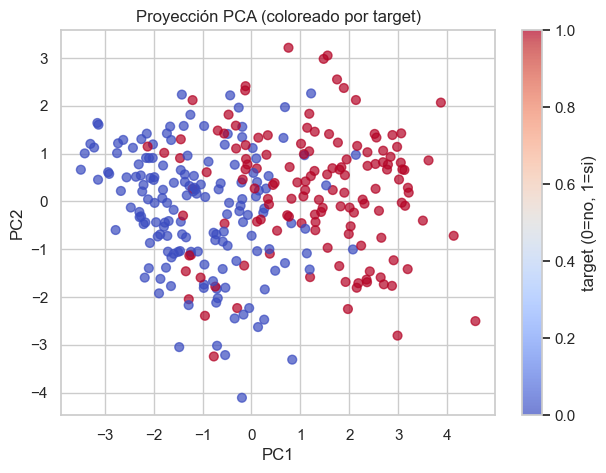

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['target'], cmap='coolwarm', s=40, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Proyección PCA (coloreado por target)')
plt.colorbar(label='target (0=no, 1=si)')
plt.show()

## Determinar número de clusters: Elbow + Silhouette

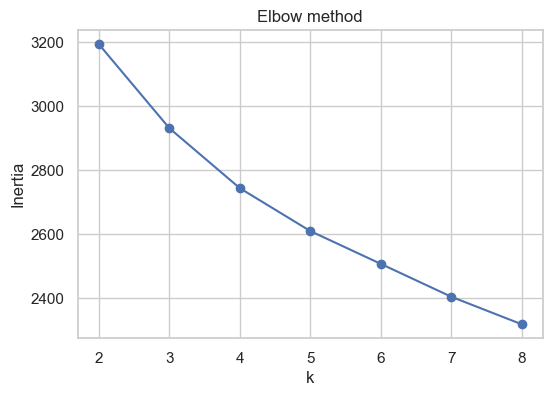

In [7]:
# Elbow (inertia)
inertias = []
K = range(2,9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
plt.figure(figsize=(6,4))
plt.plot(K, inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

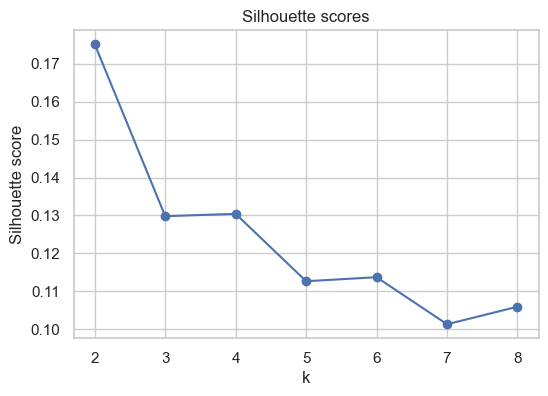

Mejor k según silhouette: 2


In [8]:
# Silhouette scores
sil = []
K = range(2,9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil.append(silhouette_score(X, labels))
plt.figure(figsize=(6,4))
plt.plot(K, sil, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette scores')
plt.show()
best_k = K[np.argmax(sil)]
print('Mejor k según silhouette:', best_k)

## Ajuste final de KMeans y análisis de clusters

In [9]:
k = int(best_k)
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X)
df['cluster'] = labels
print('Tamaño por cluster:')
print(df['cluster'].value_counts().sort_index())
print('Crosstab cluster vs target:')
display(pd.crosstab(df['cluster'], df['target']))

Tamaño por cluster:
cluster
0    184
1    113
Name: count, dtype: int64
Crosstab cluster vs target:


target,0,1
cluster,,
0,147,37
1,13,100


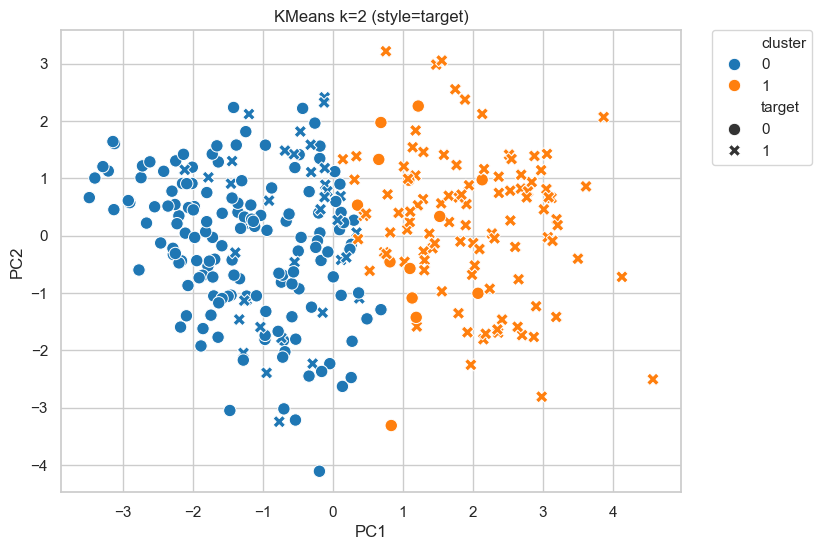

In [10]:
# Visualización de clusters en el espacio PCA, con estilo según la etiqueta real (target)
plt.figure(figsize=(8,6))
palette = sns.color_palette('tab10', n_colors=k)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], style=df['target'], palette=palette, s=80)
plt.title(f'KMeans k={k} (style=target)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

## Conclusión breve

- Este notebook muestra un flujo básico de clustering: descarga, limpieza, escalado, análisis de k (elbow/silhouette), ajuste de KMeans y visualización con PCA.
- Aunque el dataset contiene la etiqueta `target` (enfermedad), el clustering se realiza sin usarla; la etiqueta se usa solo para evaluar la correspondencia entre clusters y la condición real.
- Para producción o análisis más profundo convendría: imputar valores faltantes (en vez de eliminar filas), probar otras técnicas de clustering (DBSCAN, GaussianMixtures), y realizar selección o ingeniería de features.